### 1. Load the data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


### 2. Why this technique is needed for this dataset
Six of the columns in this dataset aren't numbers - gender, country, cancer_stage,
family_history, smoking_status, and treatment_type are all text categories. The
problem is that most ML algorithms, like SVM, Logistic Regression, K-Means, and
Neural Networks, can only work with numbers, so every one of these columns needs
to be converted before any model can use them.

The tricky part is that not every categorical column should be encoded the same
way. It depends on whether the categories have a natural order to them or not:

- For simple two-option columns like gender and family_history, a basic 0/1
  label encoding is enough there's no ranking involved, just two states.
- cancer_stage is different, because Stage I, II, III, and IV actually represent
  increasing severity. So instead of treating them as unrelated categories, I
  encoded them as ordered numbers (1 to 4), which lets the model recognize that
  Stage IV is "more severe" than Stage I.
- Columns like smoking_status, treatment_type, and country don't have any natural
  order between their options - there's no reason "Sweden" should be ranked higher
  or lower than "Malta". For these, one-hot encoding is the safer choice, since it
  avoids making the model assume a false ranking that isn't actually there.

In [6]:
print("Unique values per categorical column:\n")
for c in ["gender", "family_history", "cancer_stage", "smoking_status", "treatment_type", "country"]:
    print(f"{c} ({df[c].nunique()} levels): {sorted(df[c].unique())}")


Unique values per categorical column:

gender (2 levels): ['Female', 'Male']
family_history (2 levels): ['No', 'Yes']
cancer_stage (4 levels): ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
smoking_status (4 levels): ['Current Smoker', 'Former Smoker', 'Never Smoked', 'Passive Smoker']
treatment_type (4 levels): ['Chemotherapy', 'Combined', 'Radiation', 'Surgery']
country (27 levels): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']


### 3. Implementation

In [7]:
enc = df.copy()

# 3a. Binary nominal -> 0/1 label encoding
enc["gender_encoded"] = enc["gender"].map({"Male": 0, "Female": 1})
enc["family_history_encoded"] = enc["family_history"].map({"No": 0, "Yes": 1})

# 3b. Ordinal -> ordered integer encoding (severity order matters)
stage_order = {"Stage I": 1, "Stage II": 2, "Stage III": 3, "Stage IV": 4}
enc["cancer_stage_encoded"] = enc["cancer_stage"].map(stage_order)

# 3c. Nominal, >2 levels -> one-hot encoding
enc = pd.get_dummies(enc, columns=["smoking_status", "treatment_type"],
                      prefix=["smoking", "treatment"], dtype=int)

# country has 27 levels: one-hot would add 26 sparse columns. We keep it as a
# label-encoded id for now and note in the report that frequency- or
# target-encoding is a better option for high-cardinality columns, to be
# revisited during model design (Step 3 of the assignment).
enc["country_encoded"] = enc["country"].astype("category").cat.codes

print("New shape after encoding:", enc.shape)
enc[["gender", "gender_encoded", "family_history", "family_history_encoded",
     "cancer_stage", "cancer_stage_encoded", "country", "country_encoded"]].head()


New shape after encoding: (890000, 27)


,gender,gender_encoded,family_history,family_history_encoded,cancer_stage,cancer_stage_encoded,country,country_encoded
0,Male,0,Yes,1,Stage I,1,Sweden,26
1,Female,1,Yes,1,Stage III,3,Netherlands,19
2,Female,1,Yes,1,Stage III,3,Hungary,12
3,Female,1,No,0,Stage I,1,Belgium,1
4,Male,0,No,0,Stage I,1,Luxembourg,17


In [8]:
# Preview the one-hot columns created
onehot_cols = [c for c in enc.columns if c.startswith("smoking_") or c.startswith("treatment_")]
enc[onehot_cols].head()


,smoking_Current Smoker,smoking_Former Smoker,smoking_Never Smoked,smoking_Passive Smoker,treatment_Chemotherapy,treatment_Combined,treatment_Radiation,treatment_Surgery
0,0,0,0,1,1,0,0,0
1,0,0,0,1,0,0,0,1
2,0,1,0,0,0,1,0,0
3,0,0,0,1,1,0,0,0
4,0,0,0,1,0,1,0,0


### 4. EDA visualization

/tmp/ipykernel_1103/1020643580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="cancer_stage", order=["Stage I", "Stage II", "Stage III", "Stage IV"],
/tmp/ipykernel_1103/1020643580.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="smoking_status", ax=axes[1], palette="Oranges_d")


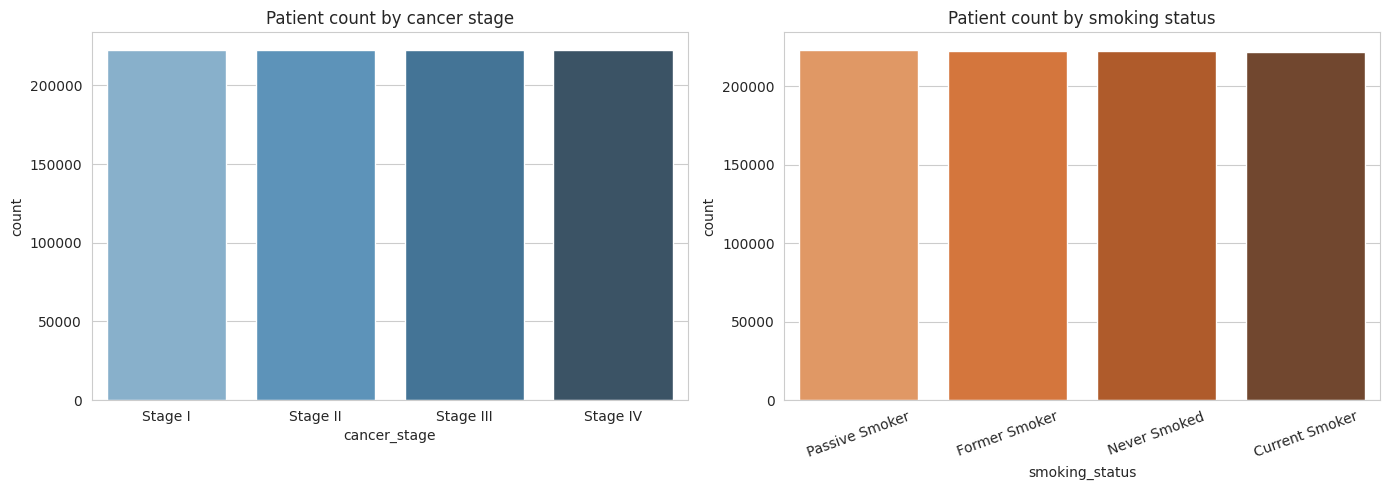

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="cancer_stage", order=["Stage I", "Stage II", "Stage III", "Stage IV"],
              ax=axes[0], palette="Blues_d")
axes[0].set_title("Patient count by cancer stage")

sns.countplot(data=df, x="smoking_status", ax=axes[1], palette="Oranges_d")
axes[1].set_title("Patient count by smoking status")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### 5. Interpretation
Looking at the bar charts, the four cancer stages are almost perfectly balanced
each one holds roughly 222,000 to 223,000 patients, right around 25% each. That's
useful because it means the ordinal encoding I used for cancer_stage isn't going
to be skewed by one stage being rare and another dominating the data.

Smoking status shows the same pattern - Current Smoker, Former Smoker, Never
Smoked, and Passive Smoker are all sitting around 22-25% of patients each, fairly
evenly spread. That matters for one-hot encoding specifically, because if one
category only had a handful of patients, its dummy column would end up almost
entirely zeros and wouldn't give the model much to learn from. Since all four
categories here are well represented, the one-hot columns for smoking_status
should be genuinely useful features rather than sparse, mostly empty ones.